In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
# -----------------------------------------------------
# STEP 2: Load Dataset
# -----------------------------------------------------
data = pd.read_csv('/content/Parkinsson disease.csv')

In [ ]:
print("Dataset Shape:", data.shape)
display(data.head())

Dataset Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
print("\nDataset Info:")
data.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-nul

In [ ]:
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [ ]:
print("\nDescriptive Statistics:")
display(data.describe())


Descriptive Statistics:


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


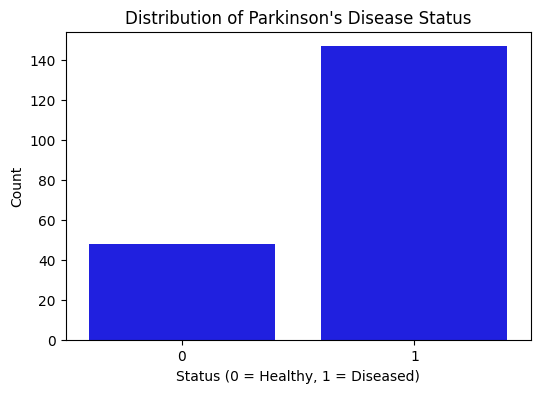

In [ ]:
# -----------------------------------------------------
# STEP 3: Exploratory Data Analysis (EDA)
# -----------------------------------------------------

# 3.1 Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=data['status'], color="blue")
plt.title("Distribution of Parkinson's Disease Status")
plt.xlabel("Status (0 = Healthy, 1 = Diseased)")
plt.ylabel("Count")
plt.show()


In [ ]:
print("\nClass Distribution:\n", data['status'].value_counts())


Class Distribution:
 status
1    147
0     48
Name: count, dtype: int64


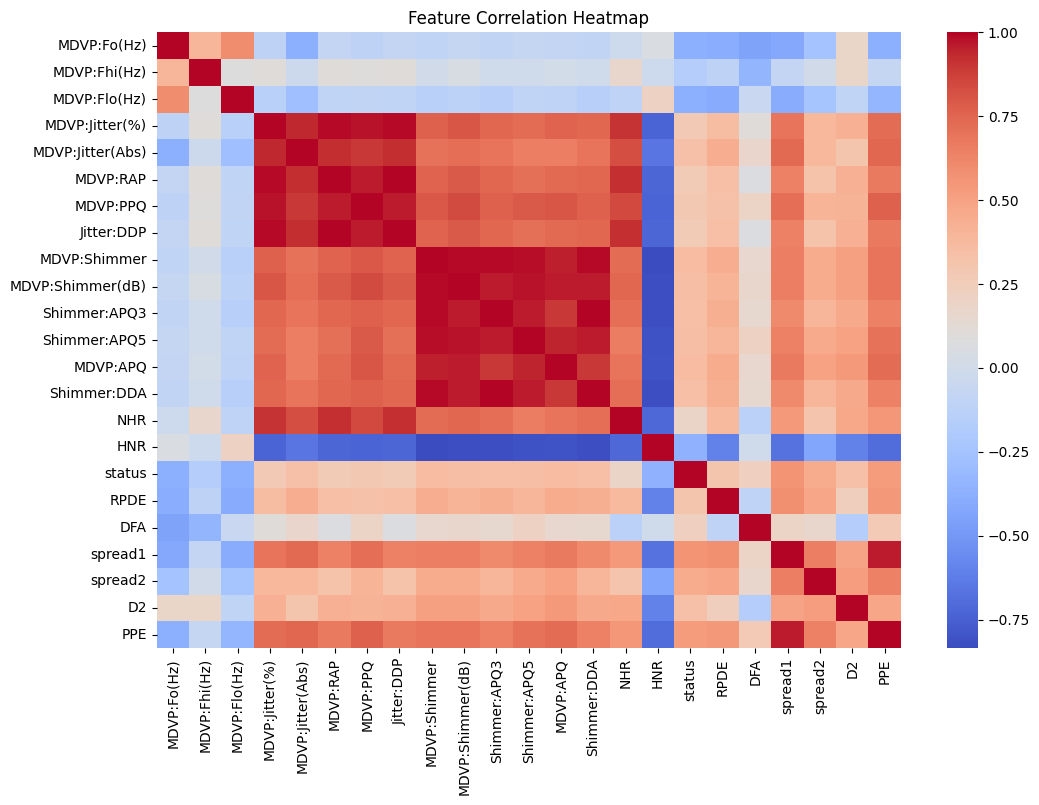

In [ ]:
# 3.2 Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.drop(columns=['name']).corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

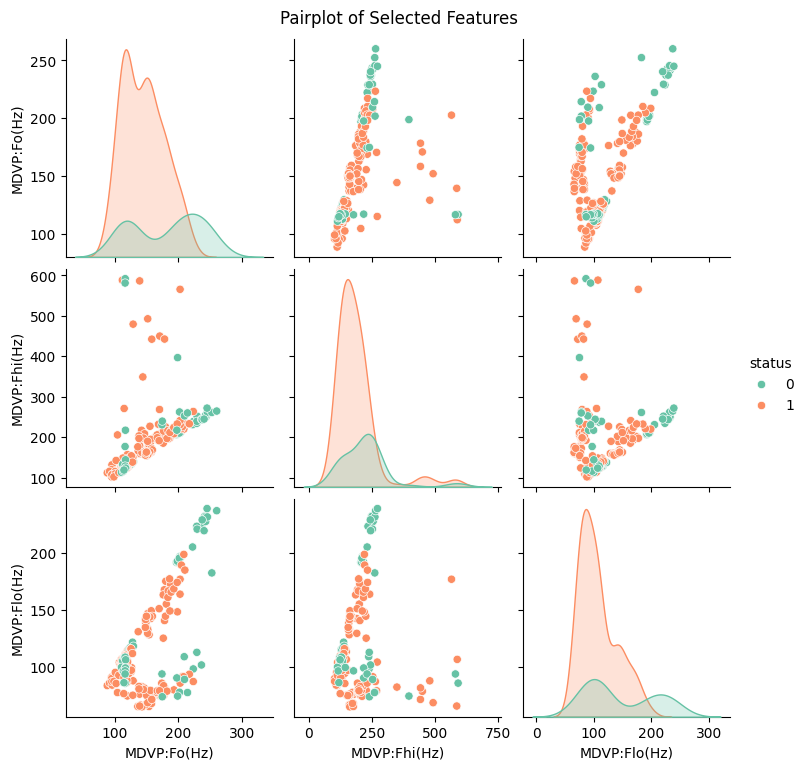

In [ ]:
# 3.3 Pairplot of selected features
sns.pairplot(data[['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'status']],
             hue='status', palette="Set2")
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

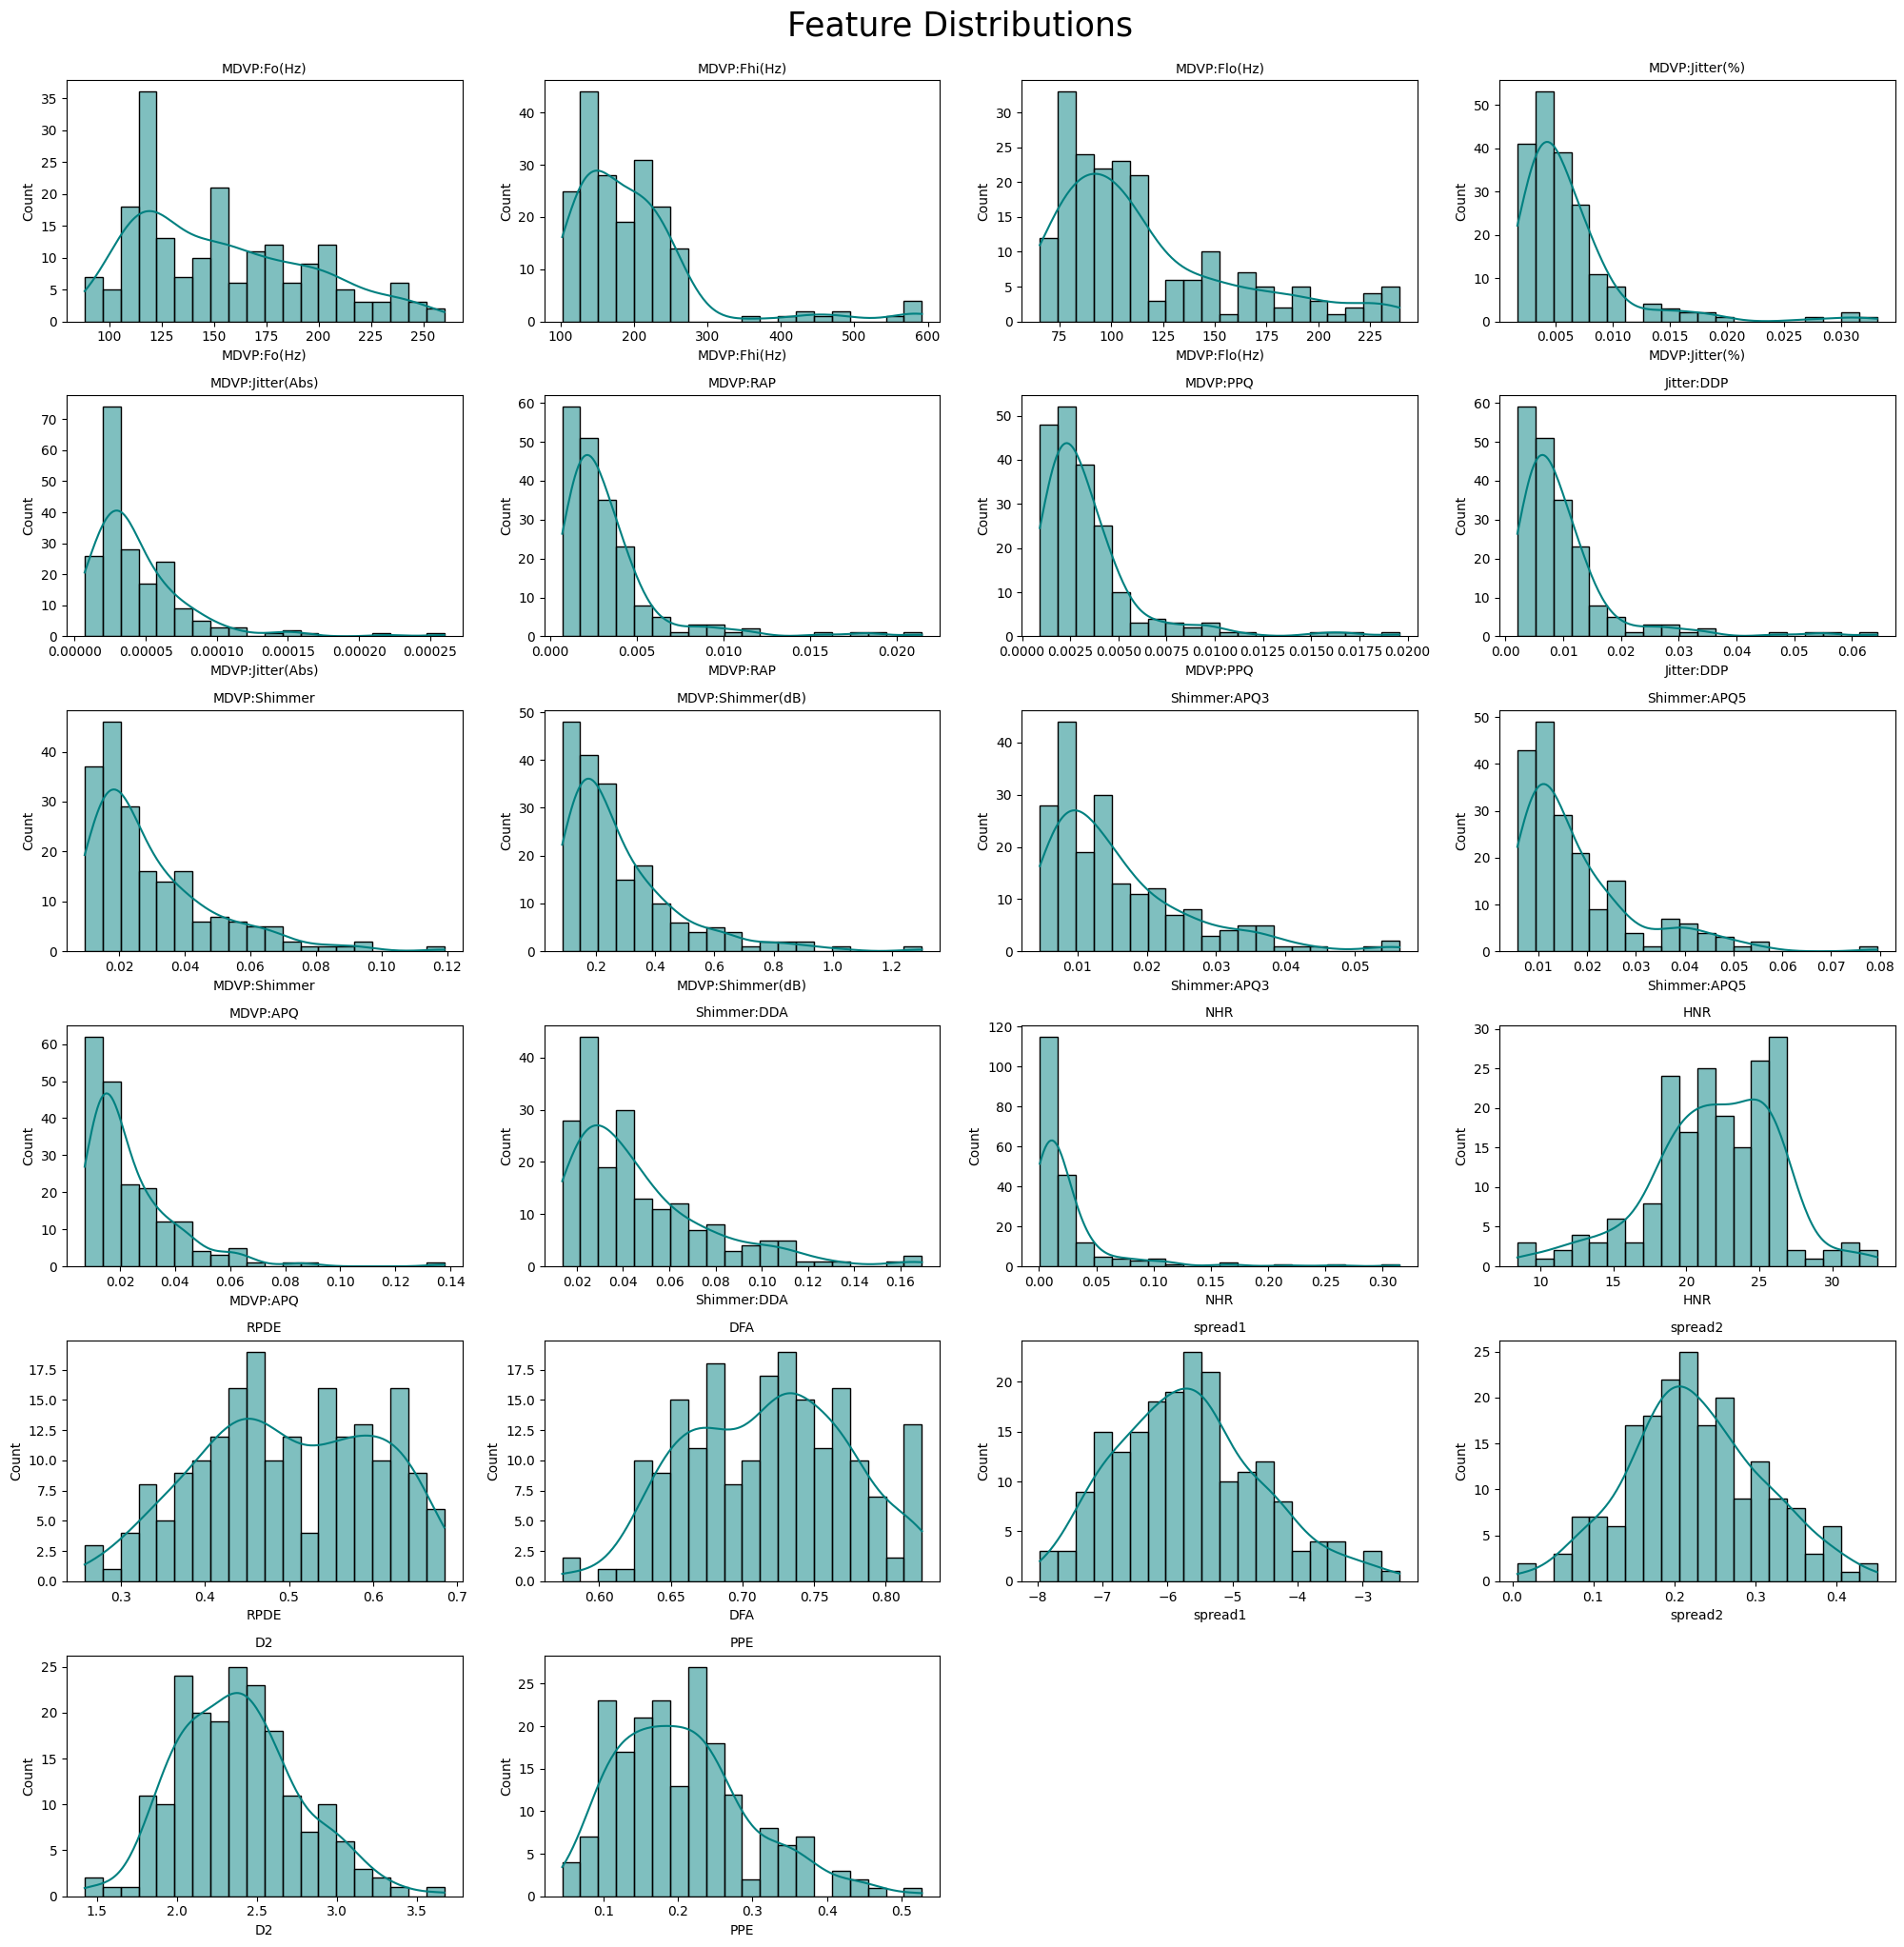

In [ ]:
# 3.4 Histogram of numeric features
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('status')
plt.figure(figsize=(20, 20))
for i, col in enumerate(numeric_cols):
    plt.subplot(6, 4, i + 1)
    sns.histplot(data[col], bins=20, kde=True, color='teal')
    plt.title(col, fontsize=10)
plt.tight_layout()
plt.suptitle("Feature Distributions", size=25, y=1.02)
plt.show()


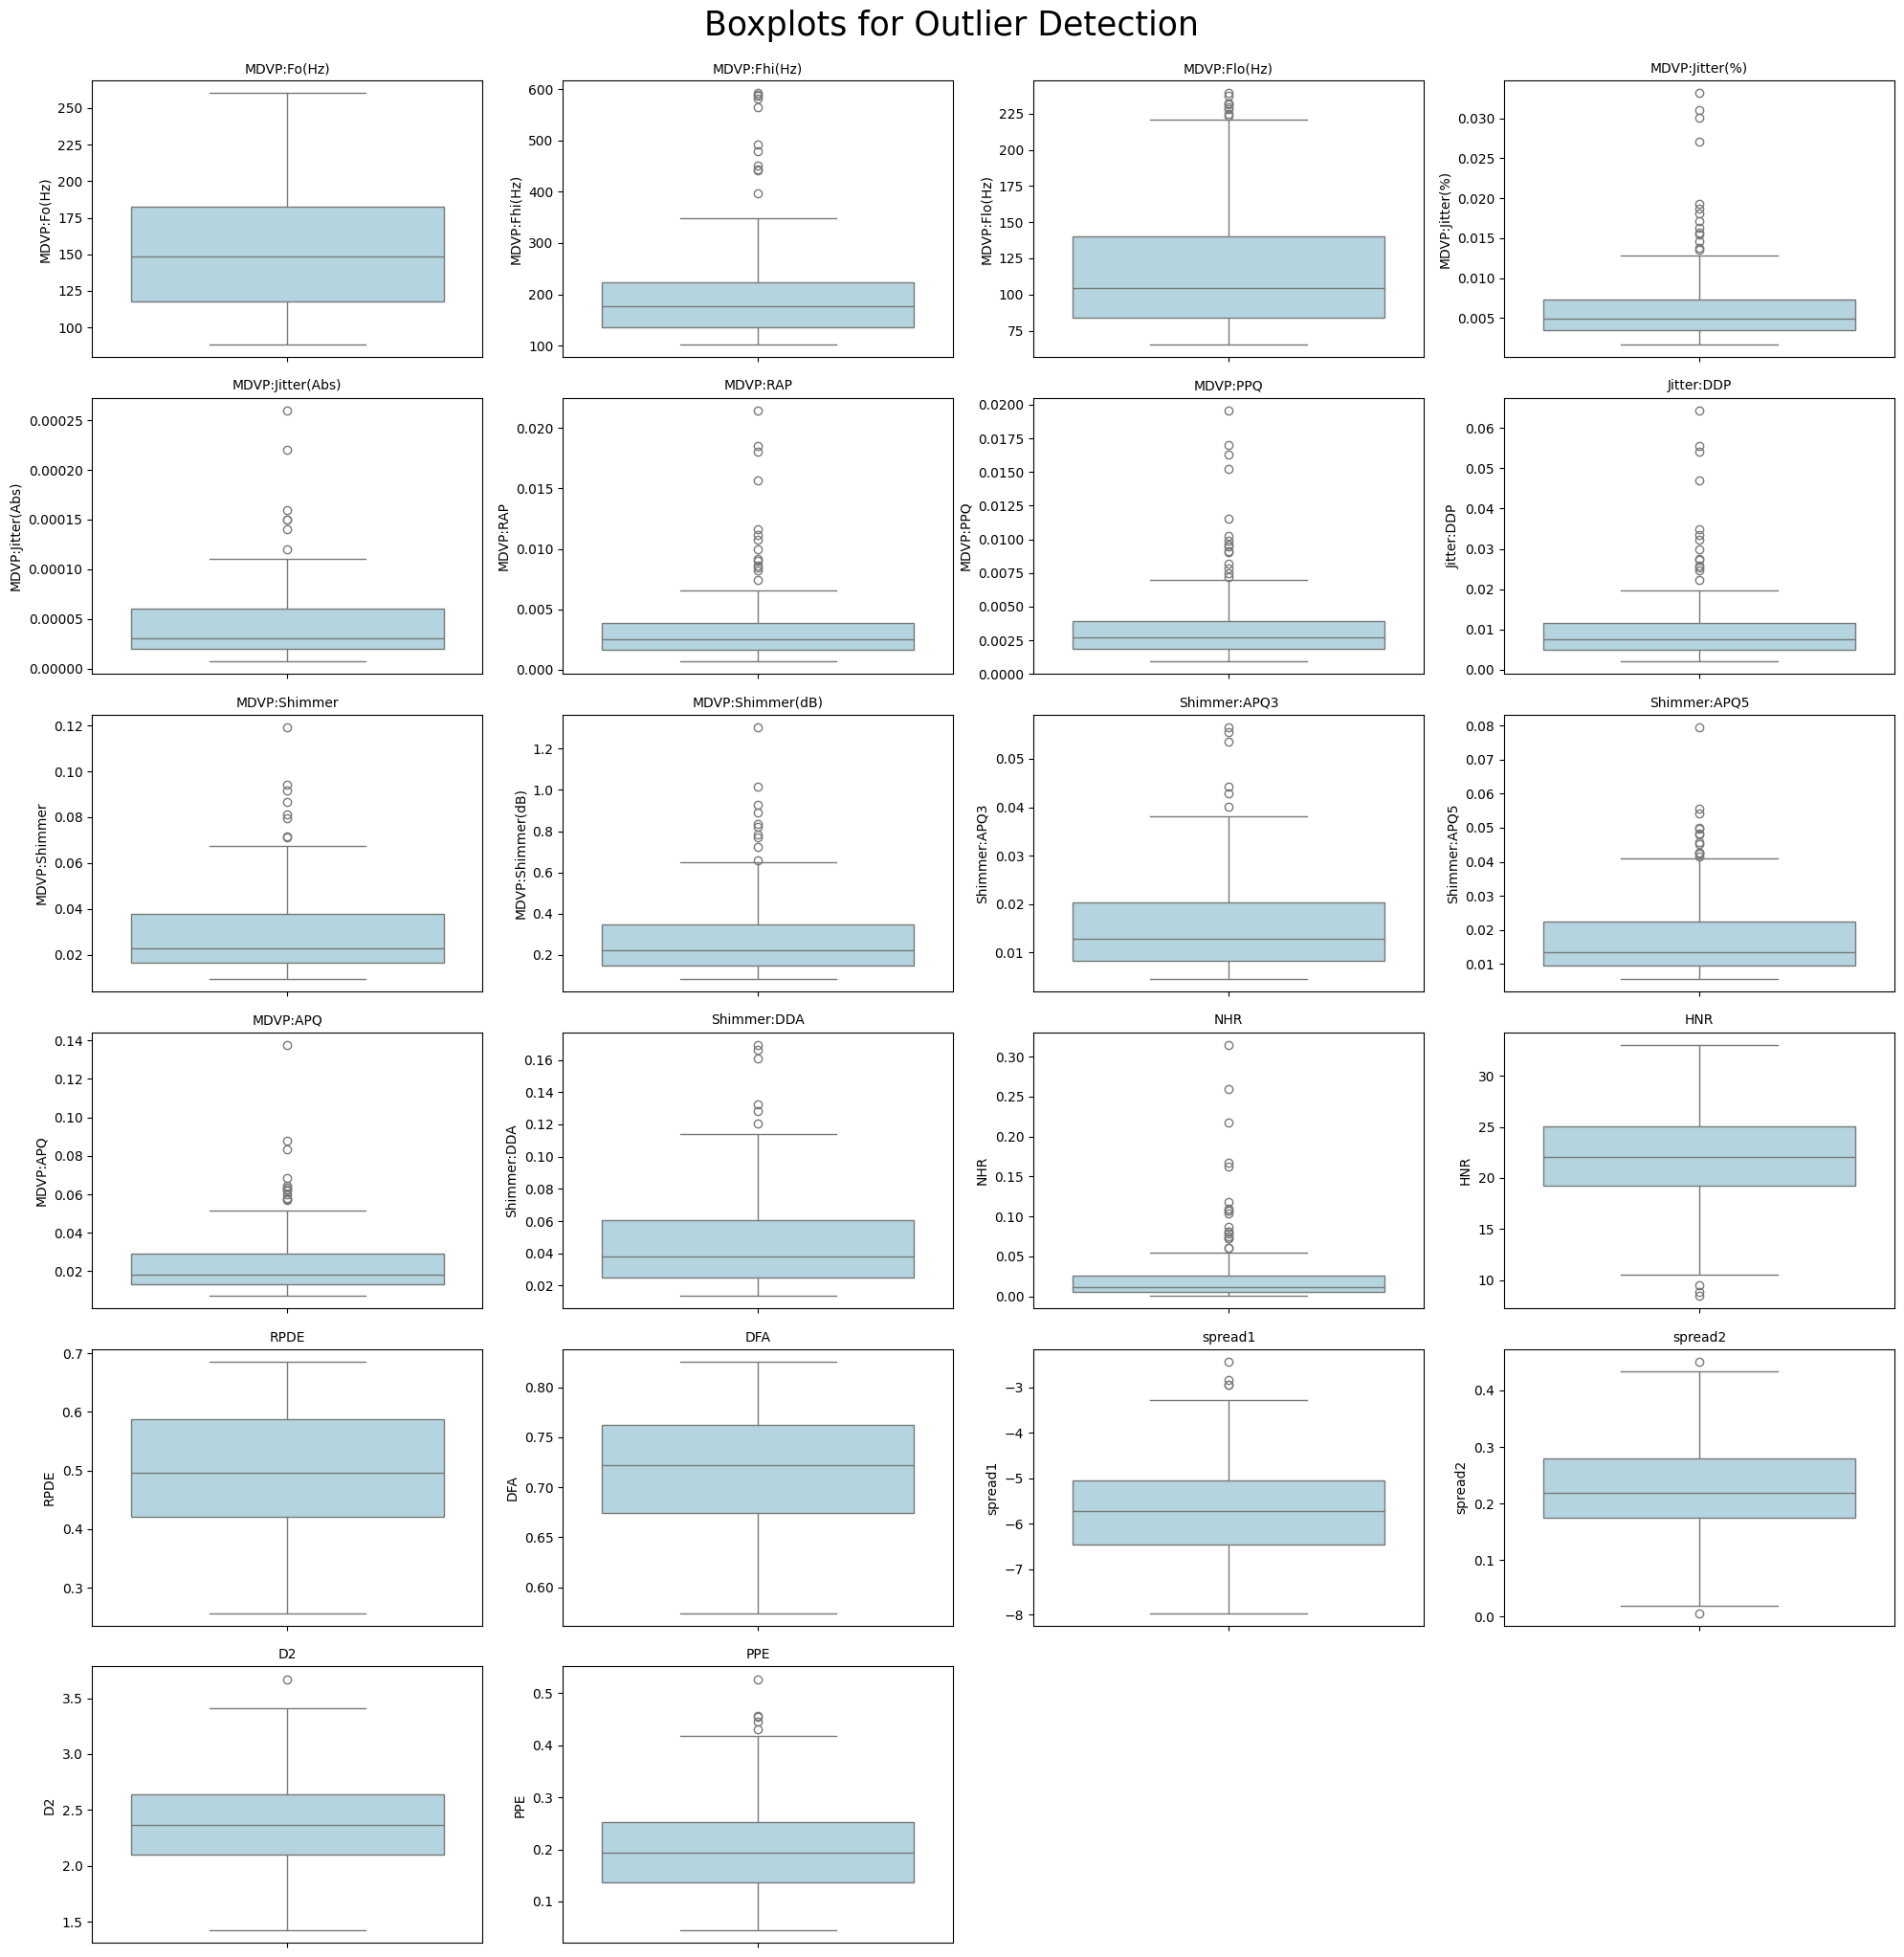

In [ ]:

# 3.5 Boxplots (to check outliers)
plt.figure(figsize=(20, 20))
for i, col in enumerate(numeric_cols):
    plt.subplot(6, 4, i + 1)
    sns.boxplot(y=data[col], color='lightblue')
    plt.title(col, fontsize=10)
plt.tight_layout()
plt.suptitle("Boxplots for Outlier Detection", size=25, y=1.02)
plt.show()

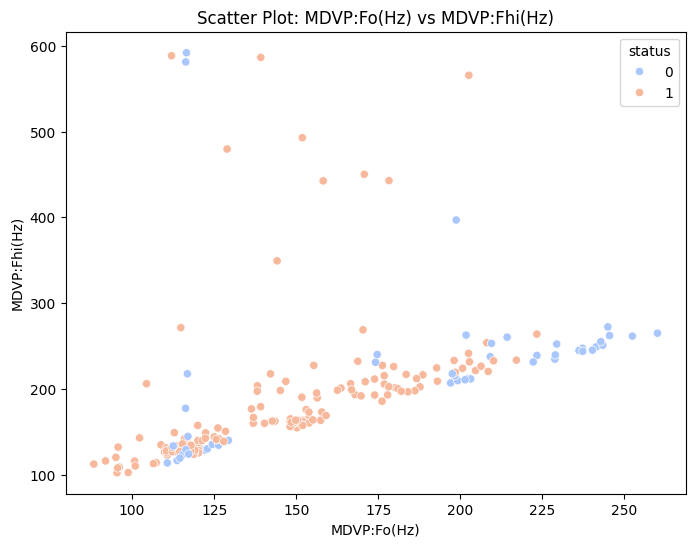

In [ ]:
# 3.6 Scatter plots for key features
plt.figure(figsize=(8, 6))
sns.scatterplot(x="MDVP:Fo(Hz)", y="MDVP:Fhi(Hz)", hue="status", data=data, palette="coolwarm")
plt.title("Scatter Plot: MDVP:Fo(Hz) vs MDVP:Fhi(Hz)")
plt.show()

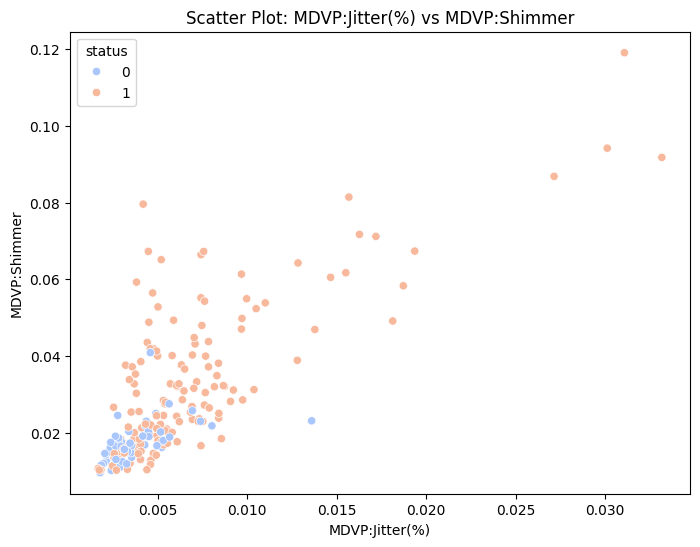

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="MDVP:Jitter(%)", y="MDVP:Shimmer", hue="status", data=data, palette="coolwarm")
plt.title("Scatter Plot: MDVP:Jitter(%) vs MDVP:Shimmer")
plt.show()

In [ ]:
# -----------------------------------------------------
# STEP 4: Data Preprocessing
# -----------------------------------------------------
X = data.drop(columns=['name', 'status'])
y = data['status']


In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (156, 22)
Testing set size: (39, 22)


In [ ]:
# -----------------------------------------------------
# STEP 5: Define Scalers and Models
# -----------------------------------------------------
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "Normalizer": Normalizer()
}


In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}

In [ ]:
# -----------------------------------------------------
# STEP 6: Train Models with Scaling before SMOTE
# -----------------------------------------------------
results = {}

for scaler_name, scaler in scalers.items():
    print(f"\n========== Using {scaler_name} ==========")

    # Scale BEFORE SMOTE
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE on scaled training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

    model_results = {}

    for model_name, model in models.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        model_results[model_name] = {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        }

        print(f"{model_name}: Accuracy={acc:.4f}, F1={f1:.4f}")

    results[scaler_name] = model_results


========== Using StandardScaler ==========
Logistic Regression: Accuracy=0.7692, F1=0.8235
SVM: Accuracy=0.8205, F1=0.8679
Random Forest: Accuracy=0.8974, F1=0.9286
KNN: Accuracy=0.9231, F1=0.9455
Naive Bayes: Accuracy=0.6410, F1=0.6957
XGBoost: Accuracy=0.9231, F1=0.9474
Gradient Boost: Accuracy=0.9487, F1=0.9655
AdaBoost: Accuracy=0.8718, F1=0.9091
Extra Trees: Accuracy=0.9487, F1=0.9655
Bagging: Accuracy=0.8462, F1=0.8889

========== Using MinMaxScaler ==========
Logistic Regression: Accuracy=0.7436, F1=0.8000
SVM: Accuracy=0.7949, F1=0.8400
Random Forest: Accuracy=0.8718, F1=0.9123
KNN: Accuracy=0.9231, F1=0.9455
Naive Bayes: Accuracy=0.6410, F1=0.6957
XGBoost: Accuracy=0.9487, F1=0.9655
Gradient Boost: Accuracy=0.9487, F1=0.9655
AdaBoost: Accuracy=0.8718, F1=0.9123
Extra Trees: Accuracy=0.9231, F1=0.9492
Bagging: Accuracy=0.8462, F1=0.8889

========== Using RobustScaler ==========
Logistic Regression: Accuracy=0.7949, F1=0.8462
SVM: Accuracy=0.7692, F1=0.8163
Random Forest: Accur

In [ ]:
# -----------------------------------------------------
# STEP 7: Accuracy Table
# -----------------------------------------------------
metrics_df = pd.DataFrame({
    (scaler, model): metrics
    for scaler, models_dict in results.items()
    for model, metrics in models_dict.items()
}).T

metrics_df.index.names = ["Scaler", "Model"]

print("\n=== METRICS TABLE ===")
display(metrics_df.round(4))



=== METRICS TABLE ===


Accuracy  Precision  Recall      F1
Scaler         Model                                                   
StandardScaler Logistic Regression    0.7692     0.9545  0.7241  0.8235
               SVM                    0.8205     0.9583  0.7931  0.8679
               Random Forest          0.8974     0.9630  0.8966  0.9286
               KNN                    0.9231     1.0000  0.8966  0.9455
               Naive Bayes            0.6410     0.9412  0.5517  0.6957
               XGBoost                0.9231     0.9643  0.9310  0.9474
               Gradient Boost         0.9487     0.9655  0.9655  0.9655
               AdaBoost               0.8718     0.9615  0.8621  0.9091
               Extra Trees            0.9487     0.9655  0.9655  0.9655
               Bagging                0.8462     0.9600  0.8276  0.8889
MinMaxScaler   Logistic Regression    0.7436     0.9524  0.6897  0.8000
               SVM                    0.7949     1.0000  0.7241  0.8400
               Random Forest          0.8718     0.9286  0.8966  0.9123
               KNN                    0.9231     1.0000  0.8966  0.9455
               Naive Bayes            0.6410     0.9412  0.5517  0.6957
               XGBoost                0.9487     0.9655  0.9655  0.9655
               Gradient Boost         0.9487     0.9655  0.9655  0.9655
               AdaBoost               0.8718     0.9286  0.8966  0.9123
               Extra Trees            0.9231     0.9333  0.9655  0.9492
               Bagging                0.8462     0.9600  0.8276  0.8889
RobustScaler   Logistic Regression    0.7949     0.9565  0.7586  0.8462
               SVM                    0.7692     1.0000  0.6897  0.8163
               Random Forest          0.8974     0.9630  0.8966  0.9286
               KNN                    0.8462     1.0000  0.7931  0.8846
               Naive Bayes            0.6410     0.9412  0.5517  0.6957
               XGBoost                0.8974     0.9310  0.9310  0.9310
               Gradient Boost         0.9487     0.9655  0.9655  0.9655
               AdaBoost               0.8718     0.9615  0.8621  0.9091
               Extra Trees            0.9231     0.9333  0.9655  0.9492
               Bagging                0.8205     0.9231  0.8276  0.8727
MaxAbsScaler   Logistic Regression    0.7436     1.0000  0.6552  0.7917
               SVM                    0.6923     1.0000  0.5862  0.7391
               Random Forest          0.8974     0.9630  0.8966  0.9286
               KNN                    0.9231     1.0000  0.8966  0.9455
               Naive Bayes            0.6410     0.9412  0.5517  0.6957
               XGBoost                0.9231     0.9333  0.9655  0.9492
               Gradient Boost         0.9231     0.9333  0.9655  0.9492
               AdaBoost               0.8462     0.9259  0.8621  0.8929
               Extra Trees            0.9231     0.9333  0.9655  0.9492
               Bagging                0.8205     0.9583  0.7931  0.8679
Normalizer     Logistic Regression    0.3590     0.6667  0.2759  0.3902
               SVM                    0.3590     0.6667  0.2759  0.3902
               Random Forest          0.8718     0.9286  0.8966  0.9123
               KNN                    0.6923     0.8696  0.6897  0.7692
               Naive Bayes            0.6667     1.0000  0.5517  0.7111
               XGBoost                0.8718     0.9286  0.8966  0.9123
               Gradient Boost         0.8462     0.9259  0.8621  0.8929
               AdaBoost               0.9231     0.9643  0.9310  0.9474
               Extra Trees            0.9231     0.9643  0.9310  0.9474
               Bagging                0.7949     0.9200  0.7931  0.8519

In [ ]:
print("\n=== ACCURACY TABLE (Scalers vs Models) ===")
display(accuracy_df.round(4))



=== ACCURACY TABLE (Scalers vs Models) ===


Model,AdaBoost,Bagging,Extra Trees,Gradient Boost,KNN,Logistic Regression,Naive Bayes,Random Forest,SVM,XGBoost
Scaler,,,,,,,,,,
MaxAbsScaler,0.8462,0.8205,0.9231,0.9231,0.9231,0.7436,0.6410,0.8974,0.6923,0.9231
MinMaxScaler,0.8718,0.8462,0.9231,0.9487,0.9231,0.7436,0.6410,0.8718,0.7949,0.9487
Normalizer,0.9231,0.7949,0.9231,0.8462,0.6923,0.3590,0.6667,0.8718,0.3590,0.8718
RobustScaler,0.8718,0.8205,0.9231,0.9487,0.8462,0.7949,0.6410,0.8974,0.7692,0.8974
StandardScaler,0.8718,0.8462,0.9487,0.9487,0.9231,0.7692,0.6410,0.8974,0.8205,0.9231


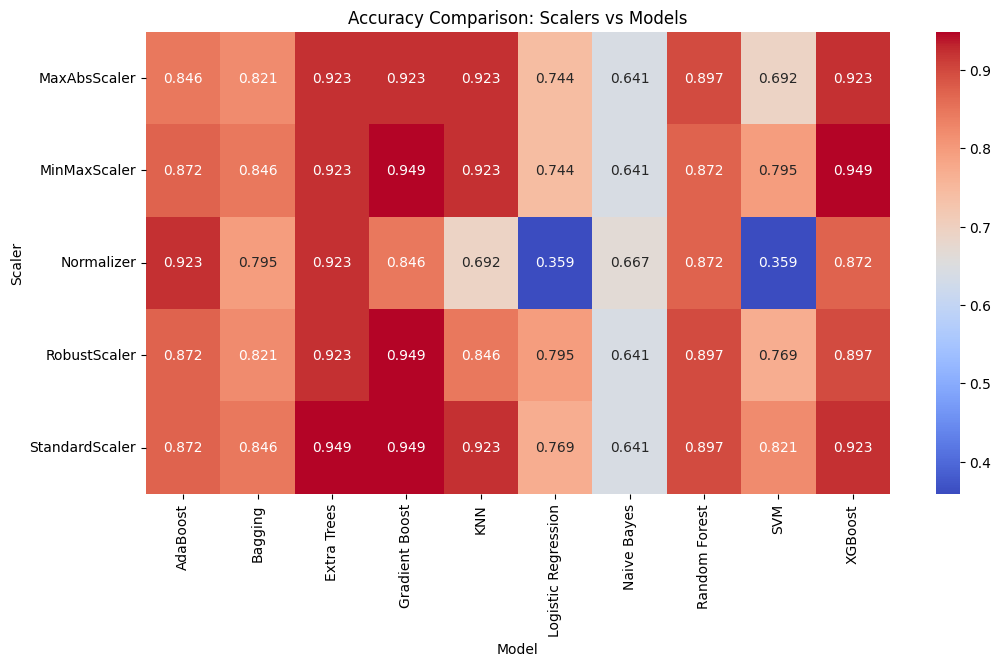

In [ ]:
# -----------------------------------------------------
# STEP 8: Visualization of Accuracy Comparison
# -----------------------------------------------------
accuracy_df = metrics_df["Accuracy"].unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(accuracy_df, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Accuracy Comparison: Scalers vs Models")
plt.show()


/tmp/ipython-input-1130057708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_acc.index, y=avg_acc.values, palette="viridis")


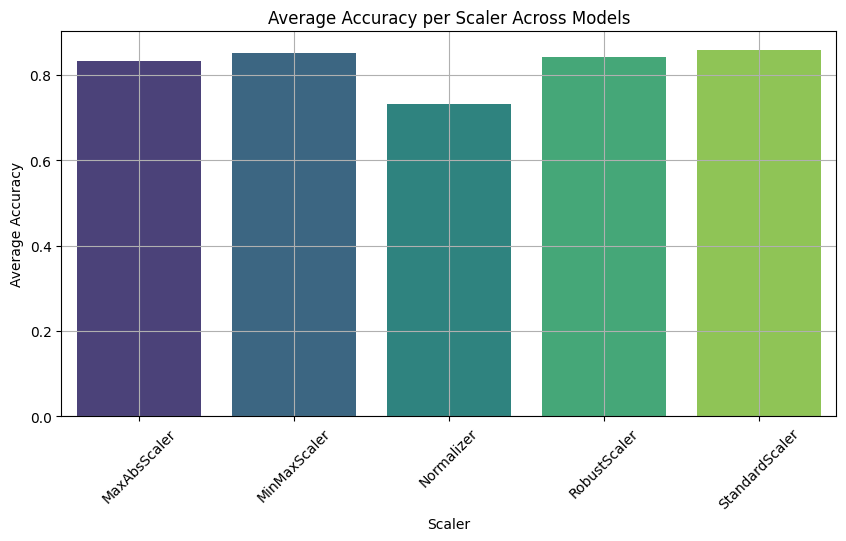

In [ ]:
# Average accuracy per scaler
avg_acc = accuracy_df.mean(axis=1)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_acc.index, y=avg_acc.values, palette="viridis")
plt.title("Average Accuracy per Scaler Across Models")
plt.ylabel("Average Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------------------------------
# STEP 9: Best Scaler & Model Summary
# -----------------------------------------------------
best_scaler = avg_acc.idxmax()
best_model = accuracy_df.loc[best_scaler].idxmax()
best_accuracy = accuracy_df.loc[best_scaler, best_model]

print(f"\n🏆 Best Scaler Overall: {best_scaler}")
print(f"🔥 Best Model: {best_model}")
print(f"🎯 Highest Accuracy: {best_accuracy:.4f}")



🏆 Best Scaler Overall: StandardScaler
🔥 Best Model: Extra Trees
🎯 Highest Accuracy: 0.9487


In [ ]:
# -----------------------------------------------------
# STEP 10: Final Evaluation of Best Model
# -----------------------------------------------------
final_scaler = scalers[best_scaler]
X_train_final_scaled = final_scaler.fit_transform(X_train)
X_test_final_scaled = final_scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_final, y_train_final = sm.fit_resample(X_train_final_scaled, y_train)

final_model = models[best_model]
final_model.fit(X_train_final, y_train_final)
y_pred_final = final_model.predict(X_test_final_scaled)

print("\n=== Final Model Classification Report ===")
print(classification_report(y_test, y_pred_final))


=== Final Model Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39

